===  Loading Data and Performing EDA ===
Dataset loaded successfully! Shape: (1338, 7)

Missing values per column:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64 



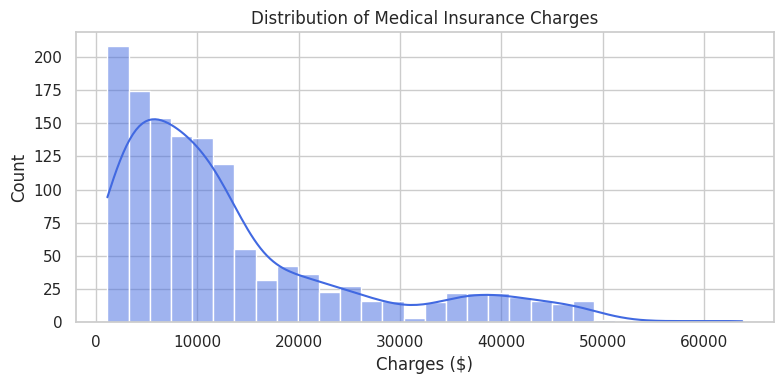

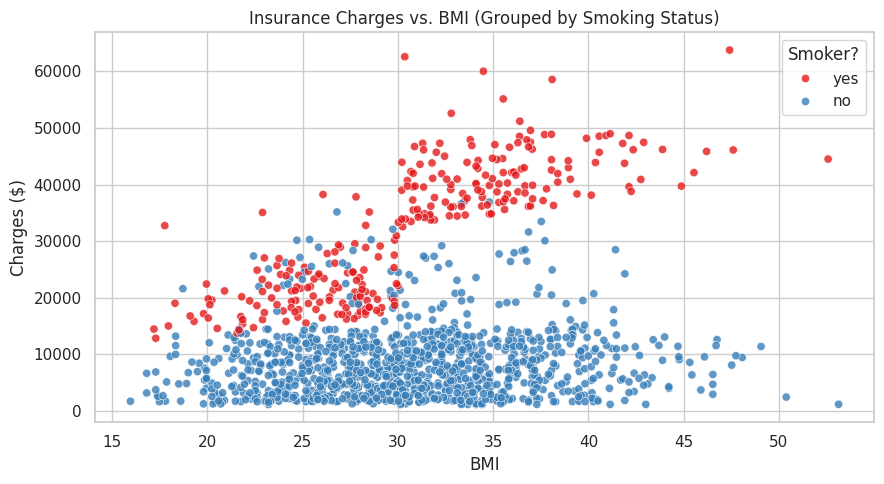


===  Setting up Preprocessing Pipeline ===
Data pipeline features partitioned and scaled correctly.

===  Training Baseline and Complex Models ===
Baseline and Complex models successfully trained.

=== Optimizing Complex Model via Grid Search ===
Best Hyperparameters Found: {'regressor__max_depth': 5, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}

=== Final Metric Evaluation ===
[Baseline Linear Regression]
  -> RMSE (Average Error Margin): $5,796.28
  -> R² Score (Variance Explained): 0.7836

[Default Random Forest]
  -> RMSE (Average Error Margin): $4,567.78
  -> R² Score (Variance Explained): 0.8656

[Tuned Random Forest]
  -> RMSE (Average Error Margin): $4,432.84
  -> R² Score (Variance Explained): 0.8734



In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


sns.set_theme(style="whitegrid")


print("===  Loading Data and Performing EDA ===")
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

print(f"Dataset loaded successfully! Shape: {df.shape}\n")
print("Missing values per column:\n", df.isnull().sum(), "\n")


plt.figure(figsize=(8, 4))
sns.histplot(df['charges'], kde=True, color='royalblue')
plt.title('Distribution of Medical Insurance Charges')
plt.xlabel('Charges ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette='Set1', alpha=0.8)
plt.title('Insurance Charges vs. BMI (Grouped by Smoking Status)')
plt.xlabel('BMI')
plt.ylabel('Charges ($)')
plt.legend(title='Smoker?')
plt.tight_layout()
plt.show()


print("\n===  Setting up Preprocessing Pipeline ===")
X = df.drop(columns=['charges'])
y = df['charges']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_features = ['age', 'bmi', 'children']
cat_features = ['sex', 'smoker', 'region']


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first'), cat_features)
    ]
)
print("Data pipeline features partitioned and scaled correctly.")
print("\n===  Training Baseline and Complex Models ===")


baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
baseline_pipeline.fit(X_train, y_train)
y_pred_base = baseline_pipeline.predict(X_test)


rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("Baseline and Complex models successfully trained.")


print("\n=== Optimizing Complex Model via Grid Search ===")

param_grid = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [None, 5, 10],
    'regressor__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Hyperparameters Found: {grid_search.best_params_}")


best_tuned_model = grid_search.best_estimator_
y_pred_tuned = best_tuned_model.predict(X_test)


print("\n=== Final Metric Evaluation ===")

def print_metrics(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"[{model_name}]")
    print(f"  -> RMSE (Average Error Margin): ${rmse:,.2f}")
    print(f"  -> R² Score (Variance Explained): {r2:.4f}\n")

print_metrics(y_test, y_pred_base, "Baseline Linear Regression")
print_metrics(y_test, y_pred_rf, "Default Random Forest")
print_metrics(y_test, y_pred_tuned, "Tuned Random Forest")

In [2]:
import pickle

with open('insurance_model.pkl', 'wb') as f:
    pickle.dump(best_tuned_model, f)

print("SUCCESS: 'insurance_model.pkl' has been created and saved!")

SUCCESS: 'insurance_model.pkl' has been created and saved!
